In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [6]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
data = pd.read_csv('AirQuality.csv' ,sep=';')

In [8]:
data

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


In [10]:
data.isnull().sum()


Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(113)

In [12]:
data.drop_duplicates()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119",NaN,NaN
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406",NaN,NaN
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139",NaN,NaN
9356,04/04/2005,14.00.00,"2,2",1071.0,-200.0,"11,9",1047.0,265.0,654.0,168.0,1129.0,816.0,"28,5","13,1","0,5028",NaN,NaN


In [13]:
data.drop(['Unnamed: 15','Unnamed: 16'], axis=1,inplace=True)

In [14]:
data

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [16]:
data['CO(GT)'] = data['CO(GT)'].astype(str).str.replace(',', '.').astype(float)
data['C6H6(GT)'] = data['C6H6(GT)'].astype(str).str.replace(',', '.').astype(float)
data['T'] = data['T'].astype(str).str.replace(',', '.').astype(float)
data['RH'] = data['RH'].astype(str).str.replace(',', '.').astype(float)
data['AH'] = data['AH'].astype(str).str.replace(',', '.').astype(float)


In [17]:
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [18]:
data.drop(['Date','Time'],axis=1,inplace=True)

In [19]:
data=data.dropna()

In [20]:
data.isna().sum()

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [21]:
data

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


In [22]:
data.shape

(9357, 13)

In [23]:
common_columns = ["CO(GT)", "NO2(GT)"]
data1 = data[common_columns + ["C6H6(GT)", "NOx(GT)"]]
data2 = data[common_columns + ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", 
                               "PT08.S4(NO2)", "PT08.S5(O3)", 
                               "T", "RH", "AH"]]


In [24]:
data1_samp = data1.head(100)
data2_samp = data2.head(100)

In [25]:
merged  = pd.merge(data1_samp,data2_samp, on = common_columns)

In [26]:
merged

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,113.0,11.9,166.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,92.0,9.4,103.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,114.0,9.0,131.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,122.0,9.2,172.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,116.0,6.5,131.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...
99,2.9,128.0,12.0,180.0,1438.0,1051.0,943.0,1668.0,1206.0,21.3,30.8,0.7696
100,2.5,121.0,12.2,160.0,1478.0,1055.0,929.0,1671.0,1262.0,19.7,36.7,0.8307
101,4.6,157.0,20.6,261.0,1808.0,1312.0,753.0,1993.0,1698.0,18.4,41.7,0.8732
102,5.9,173.0,23.1,325.0,1898.0,1381.0,681.0,2103.0,1905.0,17.6,46.1,0.9210


In [27]:
concat_rows = pd.concat([data1_samp, data2_samp], axis=0)
concat_columns = pd.concat([data1_samp,data2_samp],axis=1)

In [28]:
concat_rows

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,113.0,11.9,166.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,92.0,9.4,103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.2,114.0,9.0,131.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.2,122.0,9.2,172.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.6,116.0,6.5,131.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.9,128.0,NaN,NaN,1438.0,1051.0,943.0,1668.0,1206.0,21.3,30.8,0.7696
96,2.5,121.0,NaN,NaN,1478.0,1055.0,929.0,1671.0,1262.0,19.7,36.7,0.8307
97,4.6,157.0,NaN,NaN,1808.0,1312.0,753.0,1993.0,1698.0,18.4,41.7,0.8732
98,5.9,173.0,NaN,NaN,1898.0,1381.0,681.0,2103.0,1905.0,17.6,46.1,0.9210


In [29]:
concat_columns

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),CO(GT),NO2(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,113.0,11.9,166.0,2.6,113.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,92.0,9.4,103.0,2.0,92.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,114.0,9.0,131.0,2.2,114.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,122.0,9.2,172.0,2.2,122.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,116.0,6.5,131.0,1.6,116.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.9,128.0,12.0,180.0,2.9,128.0,1438.0,1051.0,943.0,1668.0,1206.0,21.3,30.8,0.7696
96,2.5,121.0,12.2,160.0,2.5,121.0,1478.0,1055.0,929.0,1671.0,1262.0,19.7,36.7,0.8307
97,4.6,157.0,20.6,261.0,4.6,157.0,1808.0,1312.0,753.0,1993.0,1698.0,18.4,41.7,0.8732
98,5.9,173.0,23.1,325.0,5.9,173.0,1898.0,1381.0,681.0,2103.0,1905.0,17.6,46.1,0.9210


Text(0.5, 1.0, 'Box plot')

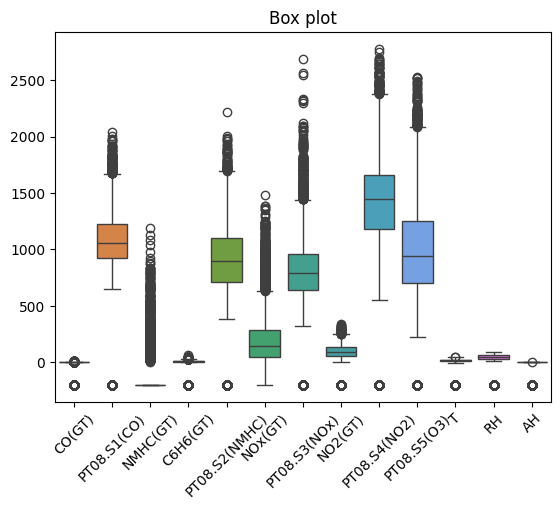

In [30]:
sns.boxplot(data)
plt.xticks(rotation=45)
plt.title('Box plot')

In [31]:
def remove_outliers_quantile(data, lower=0.01, upper=0.99):
    df = data.copy()
    numeric_cols = df.select_dtypes(include='number').columns
    
    for col in numeric_cols:
        low = df[col].quantile(lower)
        high = df[col].quantile(upper)
        df = df[(df[col] >= low) & (df[col] <= high)]
    
    return df.reset_index(drop=True)

In [32]:
cleaned_data = remove_outliers_quantile(data)

<function matplotlib.pyplot.show(close=None, block=None)>

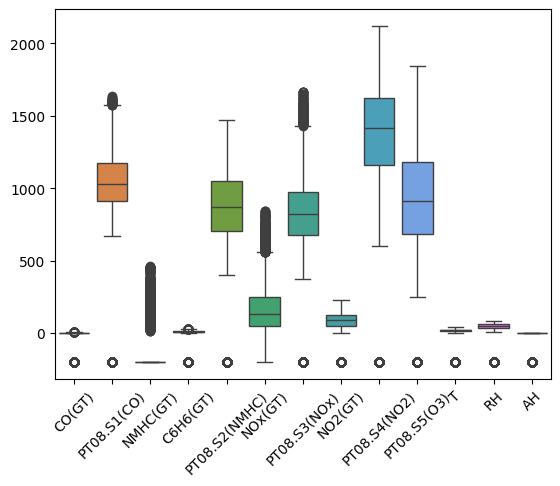

In [33]:
sns.boxplot(cleaned_data)
plt.xticks(rotation=45)
plt.show


In [34]:
from	sklearn.preprocessing	import	MinMaxScaler

scaler = MinMaxScaler()

num_cols = data.select_dtypes(include=['number']).columns

data[num_cols] = scaler.fit_transform(data[num_cols])
data.head()

C:\Users\dhanashree\AppData\Local\Temp\ipykernel_14936\3346895834.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[num_cols] = scaler.fit_transform(data[num_cols])


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,0.956111,0.696429,0.251980,0.803565,0.516156,0.217987,0.435657,0.579630,0.635966,0.539111,0.873262,0.862141,0.992715
1,0.953280,0.666071,0.224622,0.794084,0.478459,0.180465,0.476587,0.540741,0.591261,0.430408,0.872036,0.857984,0.992556
2,0.954224,0.715179,0.207343,0.792567,0.471831,0.197141,0.464794,0.581481,0.589916,0.467866,0.866312,0.879806,0.992678
3,0.954224,0.703571,0.201584,0.793326,0.475559,0.221560,0.448144,0.596296,0.599664,0.515241,0.862633,0.900589,0.992858
4,0.951392,0.657143,0.180706,0.783087,0.429163,0.197141,0.487340,0.585185,0.568067,0.481087,0.863451,0.899203,0.992869


In [35]:
# Importing libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Splitting data into input (X) and output (y)
X = data.drop('T', axis=1)
y = data['T']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# 3. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# 4. Decision Tree Regressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

# 5. Random Forest Regressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# 6. Evaluation function
def evaluate(model_name, y_test, predictions):
    print(f"\n{model_name} Results:")
    print(f"R2 Score: {r2_score(y_test, predictions):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, predictions):.2f}")
    print(f"MSE: {mean_squared_error(y_test, predictions):.2f}")
    print(f"Accuracy: {r2_score(y_test, predictions) * 100:.2f}%")

# 7. Evaluate all models
evaluate("Linear Regression", y_test, lr_preds)
evaluate("Decision Tree", y_test, dt_preds)
evaluate("Random Forest", y_test, rf_preds)



Linear Regression Results:
R2 Score: 0.99
MAE: 0.01
MSE: 0.00
Accuracy: 99.39%

Decision Tree Results:
R2 Score: 1.00
MAE: 0.00
MSE: 0.00
Accuracy: 99.98%

Random Forest Results:
R2 Score: 1.00
MAE: 0.00
MSE: 0.00
Accuracy: 99.99%
